In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import scipy.stats as sts

In [2]:
import clickhouse_connect
import pandas as pd

# Подключение к ClickHouse
client = clickhouse_connect.get_client(
    host='clickhouse.lab.karpov.courses',
    port=8123,
    username='student',
    password='dpo_python_2020',
    database='simulator_20251120'
)

Проведем А/А тестирование между нашими группами за неделю до, чтобы
1. Посмотреть на распределения глазами
2. Удостовериться, что изменения вызваны именно нашим изменением и хэширование правильно разделило наши группы

Видим,что оба распределения нормальны, а p-value различий в средних не увидел.

Размер группы 1: 8491
Размер группы 2: 8362
TtestResult(statistic=np.float64(-0.5694920635629349), pvalue=np.float64(0.5690298477939562), df=np.float64(16847.59972145556))


<Axes: xlabel='ctr', ylabel='Count'>

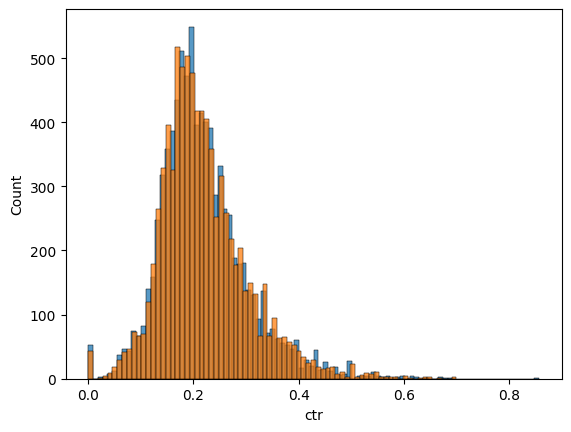

In [3]:
query_007 = '''
SELECT exp_group, 
    user_id,
    sum(action = 'like') as likes,
    sum(action = 'view') as views,
    likes/views as ctr
FROM simulator_20251120.feed_actions 
WHERE toDate(time) between '2025-10-19' and '2025-10-25'
    and exp_group in (1,2)
GROUP BY exp_group, user_id '''
df_007 = client.query_df(query_007)

group_1 = df_007[df_007.exp_group == 1].ctr # контрольная группа
group_2 = df_007[df_007.exp_group == 2].ctr # тестовая группа

print(f"Размер группы 1: {len(group_1)}")
print(f"Размер группы 2: {len(group_2)}")

p_value = sts.ttest_ind(group_1, group_2, equal_var=False)
print(p_value)

sns.histplot(group_1)
sns.histplot(group_2)

Теперь давайте посмотрим, как изменились данные после внедрения нового алгоритма. Видим, что распределение контрольной группы стало бимодальным. Обычно это означает, в рамках нашей выборки образовались 2 подгруппы, которые по разному отреагировали на наше нововведение. Левый пик не принял новые алгоритмы, правый наоборот. Еще такое бывает, когда есть проблемы с хэшированием, но данный вариаент мы уже проверили.

Я использую все тесты из лекции, чтобы, во-первых, потренироваться. Во-вторых, чтобы посмотреть/показать, как они будут справляться с оценкой.

Применив t-тест мы видим, что он не прокрасился. Хотя даже если бы он прокрасился, принимать решение на основе только этого было бы опрометчиво - бимодальное распределение не подходит для t-теста 

Размер группы 1: 10020. Размер группы 2: 9877
Контрольная группа: 0.21677399412007203. Оцениваемая группа: 0.21610168932378176

p-value =  0.6853733311407633


<Axes: xlabel='ctr', ylabel='Count'>

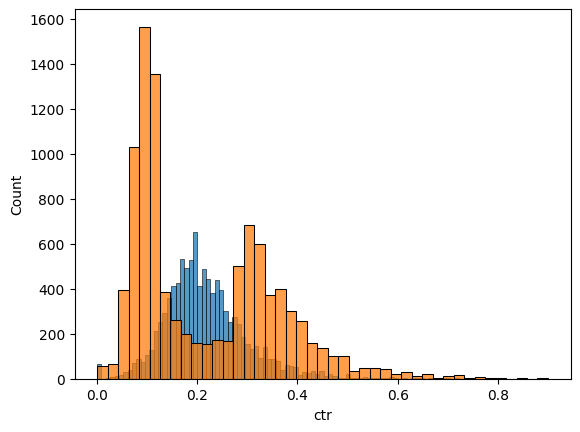

In [16]:
query = '''
SELECT exp_group, 
    user_id,
    sum(action = 'like') as likes,
    sum(action = 'view') as views,
    likes/views as ctr
FROM simulator_20251120.feed_actions 
WHERE toDate(time) between '2025-10-26' and '2025-11-01'
    and exp_group in (1,2)
GROUP BY exp_group, user_id '''
df = client.query_df(query)

group_1 = df[df.exp_group == 1].ctr # контрольная группа
group_2 = df[df.exp_group == 2].ctr # тестовая группа

print(f"Размер группы 1: {len(group_1)}. Размер группы 2: {len(group_2)}")
print(f"Контрольная группа: {np.mean(group_1)}. Оцениваемая группа: {np.mean(group_2)}\n")

p_value = sts.ttest_ind(group_1, group_2, equal_var=False)
print("p-value = ", p_value[1])


sns.histplot(group_1)
sns.histplot(group_2)


А вот непараметрический тест Манна-Уитни прокрасился, что неудивительно, ведь распределения совершенно разные. Также вычислю для наглядности эмпирическое значение

In [5]:
print(f'Отличие прокрасилось, p-value =  {sts.mannwhitneyu(group_1, group_2)[1]}')

A_gt_B = 0
for _ in range(10000):
    A_gt_B+= group_1.sample().values[0] > group_2.sample().values[0]
    
print('В', A_gt_B/100, '% случаев A > B. Должно получиться около 50%')

Отличие прокрасилось, p-value =  4.632205841806026e-45
В 54.91 % случаев A > B. Должно получиться около 50%


Сглаженный ctr показал, что различия в среднем имеют место быть. Будь у нас 2 нормальных распределения, если бы мы согласились с возможными рисками, можно было бы сказать, что мы получили статистически значимый результат. Но, как я уже писал ранее, t-тест здесь не подходит. Перейдем тогда к тяжелой артелерии - бутстрепу и бакетному тесту.

p-value =  0.0016000378013662005


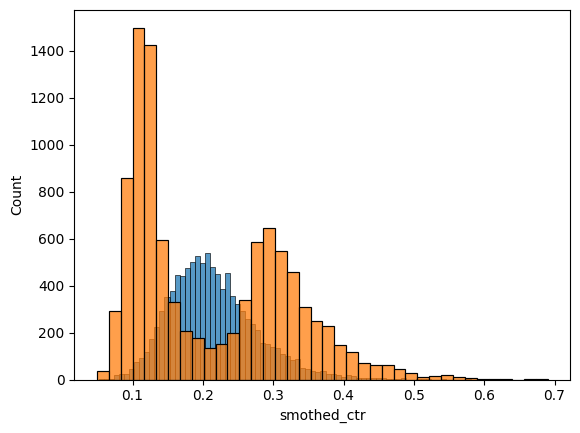

In [6]:
def get_smothed_ctr(user_likes, user_views, global_ctr, alpha):
    smothed_ctr = (user_likes + alpha * global_ctr) / (user_views + alpha)
    return smothed_ctr


global_ctr_1 = df[df.exp_group == 1].likes.sum()/df[df.exp_group == 1].views.sum()
global_ctr_2 = df[df.exp_group == 2].likes.sum()/df[df.exp_group == 2].views.sum()

group1 = df[df.exp_group == 1].copy()
group2 = df[df.exp_group == 2].copy()


group1['smothed_ctr'] = df.apply(
    lambda x: get_smothed_ctr(x['likes'], x['views'], global_ctr_1, 10), axis=1)

group2['smothed_ctr'] = df.apply(
    lambda x: get_smothed_ctr(x['likes'], x['views'], global_ctr_2, 10), axis=1)


sns.histplot(group1.smothed_ctr)
sns.histplot(group2.smothed_ctr)

p_value = sts.ttest_ind(group1.smothed_ctr, group2.smothed_ctr, equal_var=False)
print("p-value = ", p_value[1])

Бутстреп очень хорошо подходит для таких случаев с ненормальными распределениями. Согласно ЦПТ, многократное извлечение псевдовыборок сгруппирует данные вокруг среднего, сделав распределения нормального вида. 

Мы можем увидеть, что разница между нашими средними в данном случае настолько велика, что распределения даже не пересекаются

<Axes: ylabel='Count'>

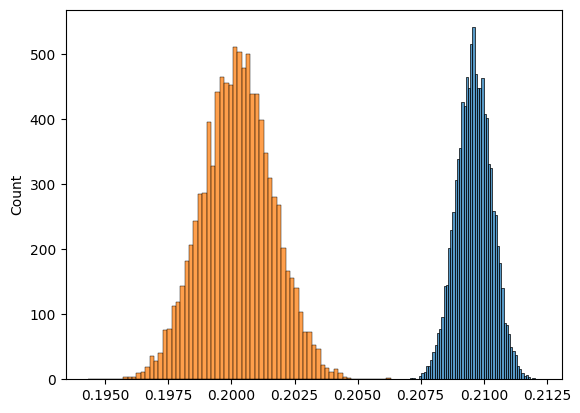

In [7]:
def bootstrap(likes1, views1, likes2, views2, n_bootstrap=10000):

    poisson_bootstraps1 = sts.poisson(1).rvs(
        (n_bootstrap, len(likes1))).astype(np.int64)

    poisson_bootstraps2 = sts.poisson(1).rvs(
            (n_bootstrap, len(likes2))).astype(np.int64)
    
    globalCTR1 = (poisson_bootstraps1*likes1).sum(axis=1)/(poisson_bootstraps1*views1).sum(axis=1)
    
    globalCTR2 = (poisson_bootstraps2*likes2).sum(axis=1)/(poisson_bootstraps2*views2).sum(axis=1)

    return globalCTR1, globalCTR2


likes1 = df[df.exp_group == 1].likes.to_numpy()
views1 = df[df.exp_group == 1].views.to_numpy()
likes2 = df[df.exp_group == 2].likes.to_numpy()
views2 = df[df.exp_group == 2].views.to_numpy()

ctr1, ctr2 = bootstrap(likes1, views1, likes2, views2)

sns.histplot(ctr1)
sns.histplot(ctr2)

Здесь мы воочию видим разницу между контрольной и тестовой группой. Так как распределение находится слева от 0, то можно сказать, что у нашей контрольной группы отрицательный результат по метрике и принимать изменения не следует. Это вывод в рамках этого теста

Следующим шагом посмотрим, что скажут нам тесты Манна-Уитни и Стьюдента поверх бакетного преобразования

<Axes: ylabel='Count'>

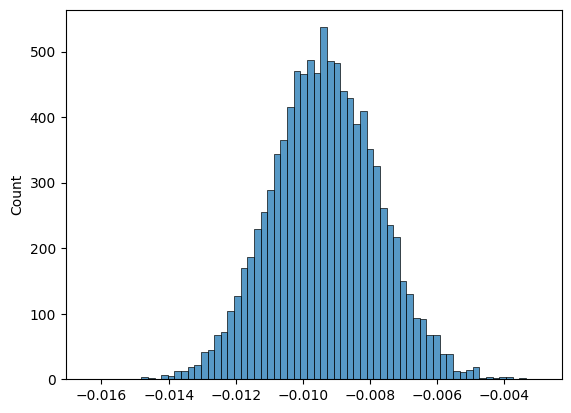

In [8]:
sns.histplot(ctr2 - ctr1)

Сделаем запрос, который разделист наших пользователей на 100 бакетов

In [13]:
query = """

SELECT exp_group, bucket,
    sum(likes)/sum(views) as bucket_ctr
FROM (SELECT exp_group, 
        xxHash64(user_id)%100 as bucket,
        user_id,
        sum(action = 'like') as likes,
        sum(action = 'view') as views,
        likes/views as ctr
    FROM simulator_20251120.feed_actions 
    WHERE toDate(time) between '2025-10-26' and '2025-11-01'
        and exp_group in (1,2)
    GROUP BY exp_group, bucket, user_id)
GROUP BY exp_group, bucket
"""

df_bucket = client.query_df(query)
display(df_bucket)

,exp_group,bucket,bucket_ctr
0,1,0,0.200050
1,2,0,0.204061
2,1,1,0.201016
3,2,1,0.198464
4,1,2,0.205225
...,...,...,...
195,2,97,0.184202
196,1,98,0.215328
197,2,98,0.202744
198,1,99,0.214422


Мы видим, что оба теста прокрасились. Тест Манна-Уитни сказал, что наши средние, медианы и проч. не равны. T-тест стал более одногорбым, но из-за явной ненормальности в изначальной выборке, батетный тест тоже имеет небольшой скос справа, хотя данные более сгруппированны по центру, чем изначально. Если принять эту ненормальность (или увеличить кол-во бакетов, сделав график более нормальным), то можно сказать, что у контрольной группы, исходя из p-value, метрика дает лучшие результаты.



Среднее контрольной: 0.20974615183351664. Среднее тестовой: 0.20044501976581613
Стандартное отклонение контрольной: 0.006919514223597016. Стандартное отклонение тестовой: 0.014160819734483486 

Тест Манна-Уитини p-value = 7.697610683936313e-09
t-test p-value = 2.4784370400633042e-08


<Axes: xlabel='bucket_ctr', ylabel='Count'>

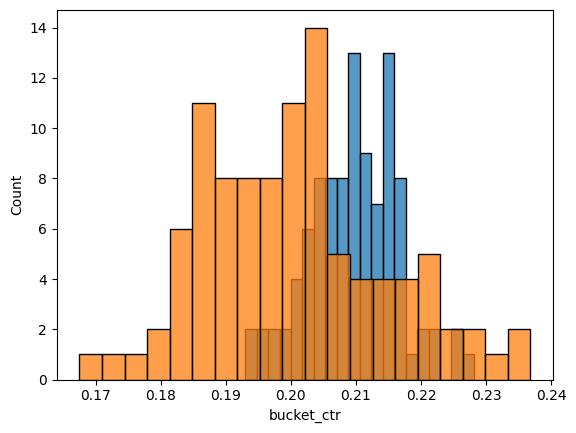

In [19]:
print(f"Среднее контрольной: {df_bucket[df_bucket.exp_group == 1].bucket_ctr.mean()}. Среднее тестовой: {df_bucket[df_bucket.exp_group == 2].bucket_ctr.mean()}")
print(f"Стандартное отклонение контрольной: {df_bucket[df_bucket.exp_group == 1].bucket_ctr.std()}. Стандартное отклонение тестовой: {df_bucket[df_bucket.exp_group == 2].bucket_ctr.std()} \n")

print(f"Тест Манна-Уитини p-value = {sts.mannwhitneyu(df_bucket[df_bucket.exp_group == 1].bucket_ctr, df_bucket[df_bucket.exp_group == 2].bucket_ctr, alternative = 'two-sided')[1]}")
print(f"t-test p-value = {sts.ttest_ind(df_bucket[df_bucket.exp_group == 1].bucket_ctr, df_bucket[df_bucket.exp_group == 2].bucket_ctr, equal_var = False)[1]}")


sns.histplot(df_bucket[df_bucket.exp_group == 1].bucket_ctr, bins=20)
sns.histplot(df_bucket[df_bucket.exp_group == 2].bucket_ctr, bins=20)

In [ ]:
#некоторые расчеты для выводов

left_peak_cnt = df[(df.exp_group == 2) & (df.ctr.between(0.02, 0.16))].user_id.count()
right_peak_cnt = df[(df.exp_group == 2) & (df.ctr.between(0.28, 0.42))].user_id.count()

left_peak_std = df[(df.exp_group == 2) & (df.ctr.between(0.02, 0.16))].ctr.std()
right_peak_std = df[(df.exp_group == 2) & (df.ctr.between(0.28, 0.42))].ctr.std()


print("Общее количество пользователей: ", df[df.exp_group == 2].user_id.count())
print(f"Кол-во пользователей в левом пике {left_peak_cnt}. В правом {right_peak_cnt}")
print(f"Стандартное отклонение ctr в левом пике {left_peak_std:.4f}. В правом {right_peak_std:.4f}")

,exp_group,user_id,likes,views,ctr
0,1,109963,3,15,0.200000
1,1,26117,32,141,0.226950
2,1,138232,18,73,0.246575
3,1,26295,39,141,0.276596
4,1,18392,7,32,0.218750
...,...,...,...,...,...
19892,2,17146,0,10,0.000000
19893,1,30872,11,59,0.186441
19894,2,25383,42,127,0.330709
19895,2,139020,17,41,0.414634


Общее количество пользователей:  9877
Кол-во пользователей в левом пике 4974. В правом 3001
Стандартное отклонение ctr в левом пике 0.0251. В правом 0.0380


<h3> Вывод </h3>

Мой вывод - не применять изменения, по крайней мере пока, и вот почему.

Смотря на бимодальное распределение тестовой группы можно увидеть, что новый алгоритм по разному оценили пользователи. По сути они разделились на 2 подгруппы. Те, кому подошел новый алгоритм - левый пик, и те, кому он не подошел - правый. Причем стандартное отклонение в левом пике явно меньше, чем в правом, а количество пользователей при этом больше. Это говорит о том, что пользователи левого пика мало того, что более "единодушны" в непринятии нашего алгоритма, так этих пользователей еще и сильно больше.

Рассмотрим 2 ситуации. 
1. Решение здесь и сейчас, если принять решение нужно быстро
2. Есть время на исследование, может после примем


Ситуация 1. Решение здесь и сейчас: 
Данные наиболее подходящих тестов (при такой сильной разнице в распределениях и отличиях от нормальности я выбрал бакетный и бутстреп), явно указывают на то, что тестовая группа хуже. Контрольная группа имеет более высокий CTR в среднем и имеет низкое стандартное отклонение.
Бутстреп показывает, что разность распределений значима и тестовая группа хуже. Бакетный тоже это показывает

Ситуация 2. Есть время на исследование
Нужно попытаться выяснить, почему в тестовой группе возникла бимодальность. Возможно, если мы это выясним, то сможем улучшить наш алгоритм для обоих подгрупп.
Нужно сегментировать пользователей тестовой группы, чтобы понять, для кого он работает, а для кого нет. Затем можно принять решение о таргетинге или доработке.

Подведем итоги: в обоих случаях мы не должны внедрять алгоритм для всех пользователей, так как в среднем он ухудшает метрику. Но при наличии времени мы можем найти сегмент, для которого он работает, и, возможно, внедрить его для этого сегмента или доработать алгоритм в целом.